# 1. Given a small dataset of 6 food delivery orders (with features like delivery_time and distance), manually create the initial distance matrix using the Euclidean distance formula between each pair of orders.<br><br><em><strong>Hint:</strong> Use the formula sqrt((x2 - x1)^2 + (y2 - y1)^2) for each pair.</em>

In [1]:
import pandas as pd
import numpy as np

In [2]:
orders = np.array([
    [15, 2.5], [20, 3.0], [45, 8.0], 
    [10, 1.5], [50, 9.5], [25, 4.0]
])

In [3]:
n = len(orders)
dist_matrix = np.zeros((n, n))

In [4]:
for i in range(n):
    for j in range(n):
        x1, y1 = orders[i]
        x2, y2 = orders[j]
        # Formula: sqrt((x2 - x1)^2 + (y2 - y1)^2)
        dist_matrix[i][j] = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

In [5]:
df_matrix = pd.DataFrame(np.round(dist_matrix, 2), 
                         columns=[f"Order {i+1}" for i in range(n)], 
                         index=[f"Order {i+1}" for i in range(n)])
print("Initial Distance Matrix:")
display(df_matrix)

Initial Distance Matrix:


,Order 1,Order 2,Order 3,Order 4,Order 5,Order 6
Order 1,0.00,5.02,30.50,5.10,35.69,10.11
Order 2,5.02,0.00,25.50,10.11,30.70,5.10
Order 3,30.50,25.50,0.00,35.60,5.22,20.40
Order 4,5.10,10.11,35.60,0.00,40.79,15.21
Order 5,35.69,30.70,5.22,40.79,0.00,25.60
Order 6,10.11,5.10,20.40,15.21,25.60,0.00


# 2. Using Python and sklearn, perform agglomerative hierarchical clustering on a dataset of 8 songs (with features like tempo and energy), and plot the resulting dendrogram using scipy's dendrogram function.

In [6]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [7]:
songs = np.array([
    [120, 8.5], [122, 8.2], [75, 3.1], [78, 3.5], 
    [128, 9.0], [130, 9.2], [80, 4.0], [82, 4.2]
])

In [8]:
song_labels = [f"Song {i+1}" for i in range(len(songs))]

In [9]:
model = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = model.fit_predict(songs)

In [10]:
linked_single = linkage(songs, method='single')

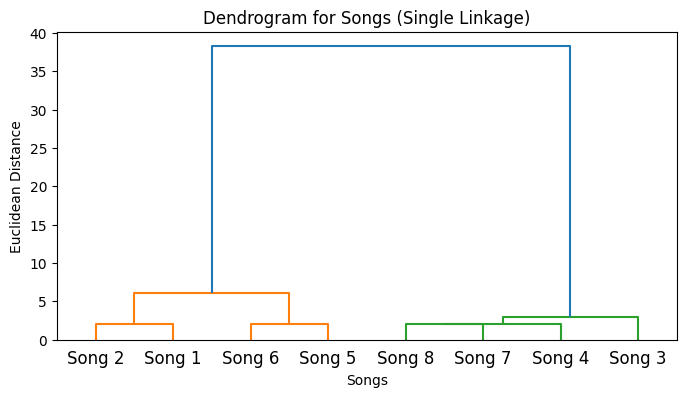

In [11]:
plt.figure(figsize=(8, 4))
dendrogram(linked_single, labels=song_labels, orientation='top', 
           distance_sort='descending', show_leaf_counts=True)
plt.title("Dendrogram for Songs (Single Linkage)")
plt.xlabel("Songs")
plt.ylabel("Euclidean Distance")
plt.show()

# 3. Change the linkage method in your clustering code from 'single' to 'complete' and 'average', and observe how the dendrogram structure changes for your songs dataset.<br><br><em><strong>Hint:</strong> Use the linkage parameter in AgglomerativeClustering or scipy's linkage function.</em>

In [12]:
linked_complete = linkage(songs, method='complete')
linked_average = linkage(songs, method='average')

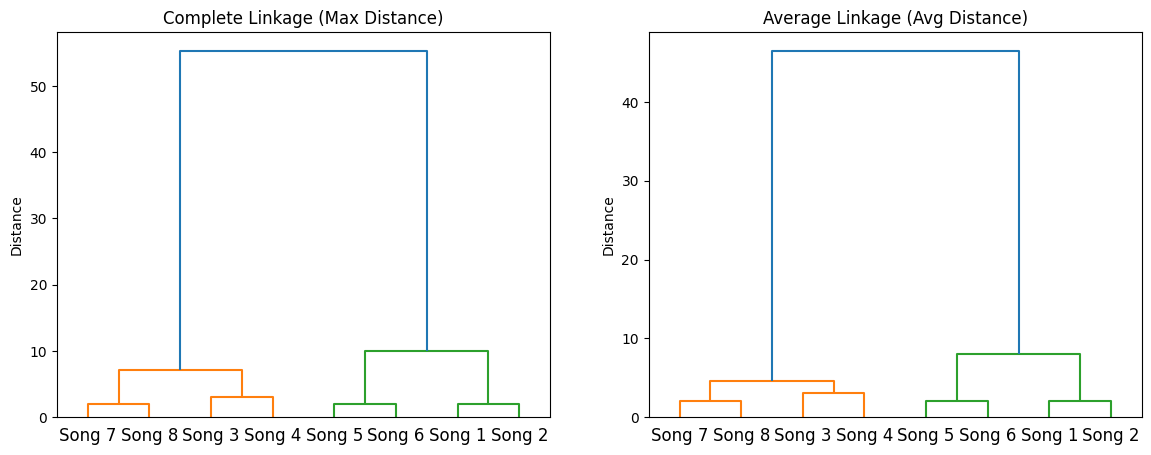

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

dendrogram(linked_complete, labels=song_labels, ax=ax1)
ax1.set_title("Complete Linkage (Max Distance)")
ax1.set_ylabel("Distance")

dendrogram(linked_average, labels=song_labels, ax=ax2)
ax2.set_title("Average Linkage (Avg Distance)")
ax2.set_ylabel("Distance")

plt.show()

When changing from Single to Complete, the dendrogram branches stretch higher because it requires a larger distance threshold to merge clusters. Average linkage strikes a balance between the two, often creating the most evenly proportioned, natural-looking groups.

# 4. Write a function that, given two points (x1, y1) and (x2, y2), returns both their Euclidean and Manhattan distances. Test it on three pairs of coordinates from your dataset.

In [14]:
def calculate_distances(p1, p2):
    euclidean = np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
    manhattan = abs(p2[0] - p1[0]) + abs(p2[1] - p1[1])
    return round(euclidean, 2), round(manhattan, 2)

In [15]:
pair_1 = (orders[0], orders[1]) 
pair_2 = (orders[2], orders[4]) 
pair_3 = (orders[3], orders[5]) 

pairs = [pair_1, pair_2, pair_3]

In [16]:
for i, (p1, p2) in enumerate(pairs):
    euc, man = calculate_distances(p1, p2)
    print(f"Test {i+1} - Points {p1} and {p2}:")
    print(f"   Euclidean: {euc} | Manhattan: {man}\n")

Test 1 - Points [15.   2.5] and [20.  3.]:
   Euclidean: 5.02 | Manhattan: 5.5

Test 2 - Points [45.  8.] and [50.   9.5]:
   Euclidean: 5.22 | Manhattan: 6.5

Test 3 - Points [10.   1.5] and [25.  4.]:
   Euclidean: 15.21 | Manhattan: 17.5



# 5. Imagine you are building a 'similar movies' feature for a movie app. Briefly describe which linkage method (single, complete, average, or Ward) you would choose for grouping movies by user ratings and why.

**Choose Ward's Method**

For a "similar movies" feature based on user ratings, you want to group movies into tight, naturally cohesive clusters (e.g., Action fans, Rom-Com fans).

Single linkage would perform poorly here because of the "chaining effect"—if one movie crosses genres, it could accidentally chain completely unrelated movies together.

Complete linkage is too sensitive to outliers (e.g., one user giving a 1-star troll rating to a masterpiece).

Ward's method minimizes the variance within the clusters, ensuring that the movies recommended to a user are tightly related to each other without being thrown off by a few weird user ratings.